# LSTM Classifier for Article Bias Prediction

This notebook builds a deep learning model using LSTM (Long Short-Term Memory) networks to classify news articles by their political bias (left, center, right).

**Data Source**: Article-Bias-Prediction dataset with JSON articles
**Model**: LSTM with embedding layer
**Task**: Multi-class text classification

In [1]:
import os
import json
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.preprocessing import LabelEncoder

import pickle

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

I0000 00:00:1781634003.500779 1544367 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781634003.544603 1544367 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1781634004.433760 1544367 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0
GPU Available: []


W0000 00:00:1781634005.043141 1544367 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## 1. Load and Parse JSON Data

Load all JSON files from the Article-Bias-Prediction dataset and convert to a structured DataFrame.

In [2]:
# Set paths relative to the Bias Classifier project root.
# Run this notebook from C:/jh/python2/Bias Classifier or another checkout root.
PROJECT_ROOT = Path.cwd()
data_dir = PROJECT_ROOT / 'Article-Bias-Prediction-main' / 'data' / 'jsons'
if not data_dir.exists():
    raise FileNotFoundError(
        f"Training JSON directory not found: {data_dir}. "
        "Restore Article-Bias-Prediction-main/data/jsons from the local dataset before running."
    )
json_files = glob.glob(str(data_dir / '*.json'))
print(f"Found {len(json_files)} JSON files")

# Load all JSON files into a list
data_list = []
for json_file in json_files:
    try:
        with open(json_file, 'r', encoding='utf-8') as f:
            article = json.load(f)
            data_list.append(article)
    except Exception as e:
        print(f"Error loading {json_file}: {e}")

print(f"Successfully loaded {len(data_list)} articles")

# Convert to DataFrame
df = pd.DataFrame(data_list)
print(f"\nDataFrame shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst row:\n{df.iloc[0]}")

Found 37554 JSON files


Successfully loaded 37554 articles

DataFrame shape: (37554, 12)

Columns: ['topic', 'source', 'bias', 'url', 'title', 'date', 'authors', 'content', 'content_original', 'source_url', 'bias_text', 'ID']

First row:
topic                                                       terrorism
source                                          New York Times - News
bias                                                                0
url                 http://www.nytimes.com/2016/09/20/nyregion/ahm...
title               Bomb Suspect Changed After Trip Abroad, Friend...
date                                                       2016-09-20
authors                                              N. R. Kleinfield
content             Besides his most recent trip to Quetta , Mr. R...
content_original    Besides his most recent trip to Quetta, Mr. Ra...
source_url                                            www.nytimes.com
bias_text                                                        left
ID              

## 2. Exploratory Data Analysis

Analyze the structure, class distribution, and text statistics of the dataset.

Bias Distribution:
bias_text
right     13734
left      13005
center    10815
Name: count, dtype: int64

Bias percentages:
bias_text
right     36.571337
left      34.630133
center    28.798530
Name: proportion, dtype: float64


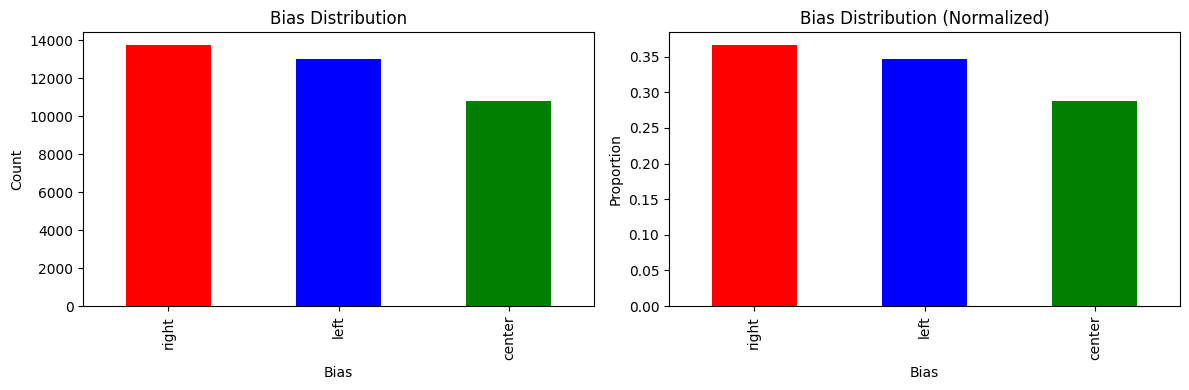


Missing values:
topic               0
source              0
bias                0
url                 0
title               0
date                0
authors             0
content             0
content_original    0
source_url          0
bias_text           0
ID                  0
dtype: int64



Text statistics:
Average content length: 5848 characters
Average word count: 1084 words
Min/Max content length: 131/53992
Min/Max word count: 26/9703


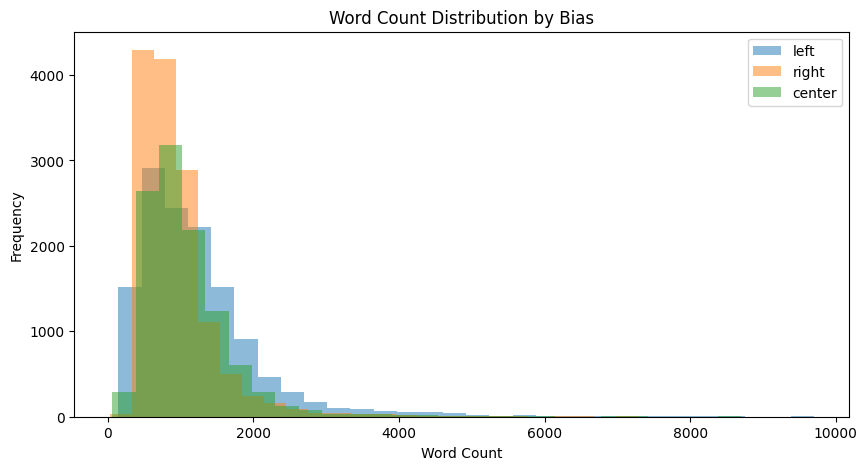


Sample articles by bias:

left: Besides his most recent trip to Quetta , Mr. Rahami visited Karachi , Pakistan , in 2005 . Both of those cities ’ reputations have become entwined with the militant groups who have sheltered there : K...

right: House Speaker Paul Ryan , at a private dinner earlier this year , said he thought only “ one member ” wanted to build a wall across the entire U.S.-Mexico border , ███ has learned from multiple source...

center: The left believes Sanders ’ s chances have improved , but notes that obstacles still remain .
“ Sanders reportedly pulled in about $ 34.5 million in the fourth quarter of 2019 , which makes for a tota...


In [3]:
# Check bias_text distribution
print("Bias Distribution:")
print(df['bias_text'].value_counts())
print(f"\nBias percentages:\n{df['bias_text'].value_counts(normalize=True) * 100}")

# Visualize bias distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['bias_text'].value_counts().plot(kind='bar', ax=axes[0], color=['red', 'blue', 'green'])
axes[0].set_title('Bias Distribution')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Bias')

df['bias_text'].value_counts(normalize=True).plot(kind='bar', ax=axes[1], color=['red', 'blue', 'green'])
axes[1].set_title('Bias Distribution (Normalized)')
axes[1].set_ylabel('Proportion')
axes[1].set_xlabel('Bias')
plt.tight_layout()
plt.show()

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Text statistics
df['content_length'] = df['content'].fillna('').apply(len)
df['word_count'] = df['content'].fillna('').apply(lambda x: len(x.split()))

print("\nText statistics:")
print(f"Average content length: {df['content_length'].mean():.0f} characters")
print(f"Average word count: {df['word_count'].mean():.0f} words")
print(f"Min/Max content length: {df['content_length'].min()}/{df['content_length'].max()}")
print(f"Min/Max word count: {df['word_count'].min()}/{df['word_count'].max()}")

# Show word count distribution by bias
fig, ax = plt.subplots(figsize=(10, 5))
for bias in df['bias_text'].unique():
    data = df[df['bias_text'] == bias]['word_count']
    ax.hist(data, alpha=0.5, label=bias, bins=30)
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.set_title('Word Count Distribution by Bias')
ax.legend()
plt.show()

# Sample articles
print("\nSample articles by bias:")
for bias in df['bias_text'].unique():
    sample = df[df['bias_text'] == bias]['content'].iloc[0][:200]
    print(f"\n{bias}: {sample}...")

## 3. Preprocess Text Data

Clean and normalize the text data for model input.

In [4]:
import re
import string

def preprocess_text(text):
    """Clean and preprocess text"""
    if pd.isna(text):
        return ""
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply preprocessing
print("Preprocessing text data...")
df['text_cleaned'] = df['content'].apply(preprocess_text)

# Remove empty texts
df = df[df['text_cleaned'].str.len() > 0].reset_index(drop=True)
print(f"Articles after removing empty texts: {len(df)}")

# Encode labels
label_encoder = LabelEncoder()
df['bias_encoded'] = label_encoder.fit_transform(df['bias_text'])

print("\nLabel mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {i}: {label}")

print(f"\nSample preprocessed text:\n{df['text_cleaned'].iloc[0][:300]}...")
print(f"\nLabel: {df['bias_text'].iloc[0]} -> {df['bias_encoded'].iloc[0]}")

Preprocessing text data...


Articles after removing empty texts: 37554

Label mapping:
  0: center
  1: left
  2: right

Sample preprocessed text:
besides his most recent trip to quetta mr rahami visited karachi pakistan in both of those cities reputations have become entwined with the militant groups who have sheltered there karachi as a haven for the pakistani taliban and al qaeda and quetta as the headquarters of the exiled afghan taliban l...

Label: left -> 1


## 4. Tokenize and Encode Text

Convert text to sequences of integers and pad to fixed length.

In [5]:
# Parameters
MAX_WORDS = 5000  # Vocabulary size
MAX_SEQUENCE_LENGTH = 500  # Max length of sequence

# Create tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(df['text_cleaned'].values)

# Convert text to sequences
X = tokenizer.texts_to_sequences(df['text_cleaned'].values)

# Pad sequences
X = pad_sequences(X, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

# Prepare labels
y = df['bias_encoded'].values

print(f"Tokenizer vocabulary size: {len(tokenizer.word_index)}")
print(f"Sequence shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"\nSequence length statistics:")
print(f"  Max: {len(tokenizer.word_index)}")
print(f"  Vocab size used: {min(MAX_WORDS, len(tokenizer.word_index))}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Class distribution in train set: {np.bincount(y_train)}")
print(f"Class distribution in test set: {np.bincount(y_test)}")

Tokenizer vocabulary size: 186758
Sequence shape: (37554, 500)
Labels shape: (37554,)

Sequence length statistics:
  Max: 186758
  Vocab size used: 5000

Train set size: 30043
Test set size: 7511
Class distribution in train set: [ 8652 10404 10987]
Class distribution in test set: [2163 2601 2747]


## 5. Build LSTM Model Architecture

Design the neural network with embedding, bidirectional LSTM, and dense layers.

In [6]:
# Model parameters
EMBEDDING_DIM = 128
LSTM_UNITS = 64
DROPOUT_RATE = 0.5
NUM_CLASSES = len(label_encoder.classes_)

# Build model
model = Sequential([
    # Embedding layer
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_SEQUENCE_LENGTH,
        name='embedding'
    ),
    
    # Dropout for regularization
    Dropout(DROPOUT_RATE),
    
    # Bidirectional LSTM
    Bidirectional(LSTM(LSTM_UNITS, return_sequences=True), name='bidirectional_lstm_1'),
    Dropout(DROPOUT_RATE),
    
    # Second LSTM layer
    Bidirectional(LSTM(LSTM_UNITS), name='bidirectional_lstm_2'),
    Dropout(DROPOUT_RATE),
    
    # Dense layers
    Dense(128, activation='relu', name='dense_1'),
    Dropout(DROPOUT_RATE),
    
    Dense(64, activation='relu', name='dense_2'),
    Dropout(DROPOUT_RATE),
    
    # Output layer
    Dense(NUM_CLASSES, activation='softmax', name='output')
])

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_lstm_1            │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_lstm_2            │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 6. Train the LSTM Classifier

Compile and train the model on the training data.

In [7]:
# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Train model
print("Training model...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

print("\nTraining completed!")

Training model...


Epoch 1/15


  1/939 ━━━━━━━━━━━━━━━━━━━━ 57:21 4s/step - accuracy: 0.3125 - loss: 1.1030

  2/939 ━━━━━━━━━━━━━━━━━━━━ 3:25 220ms/step - accuracy: 0.3281 - loss: 1.1017

  3/939 ━━━━━━━━━━━━━━━━━━━━ 3:32 227ms/step - accuracy: 0.3264 - loss: 1.1013

...

939/939 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.7719 - loss: 0.5896

939/939 ━━━━━━━━━━━━━━━━━━━━ 222s 237ms/step - accuracy: 0.7644 - loss: 0.6007 - val_accuracy: 0.6321 - val_loss: 0.9531


Epoch 6: early stopping


Restoring model weights from the end of the best epoch: 3.



Training completed!


## 7. Evaluate Model Performance

Assess the model using various metrics and visualizations.

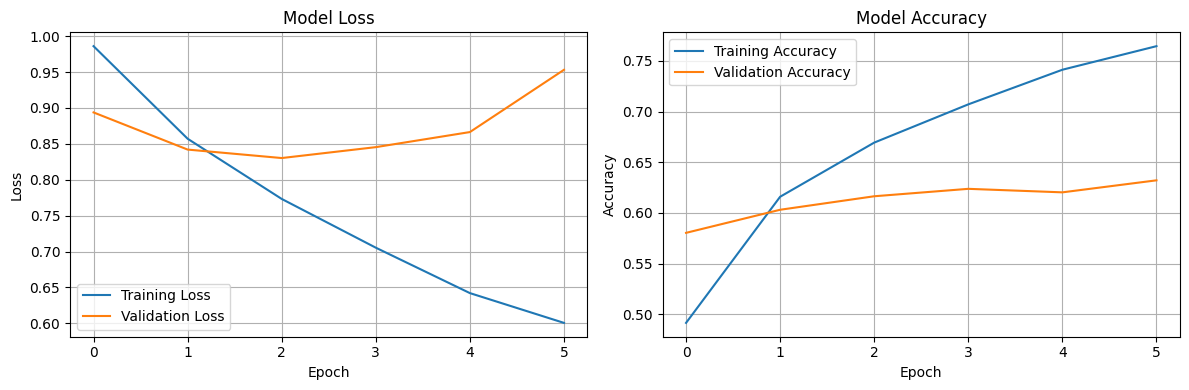

  1/235 ━━━━━━━━━━━━━━━━━━━━ 1:25 366ms/step

  2/235 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step  

  3/235 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step

  4/235 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step

  6/235 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step

...

231/235 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step

233/235 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step

235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step

235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step



Test Accuracy: 0.6164

Classification Report:
              precision    recall  f1-score   support

      center       0.67      0.51      0.58      2163
        left       0.60      0.61      0.61      2601
       right       0.60      0.70      0.65      2747

    accuracy                           0.62      7511
   macro avg       0.62      0.61      0.61      7511
weighted avg       0.62      0.62      0.61      7511


Confusion Matrix:
[[1104  534  525]
 [ 253 1594  754]
 [ 294  521 1932]]


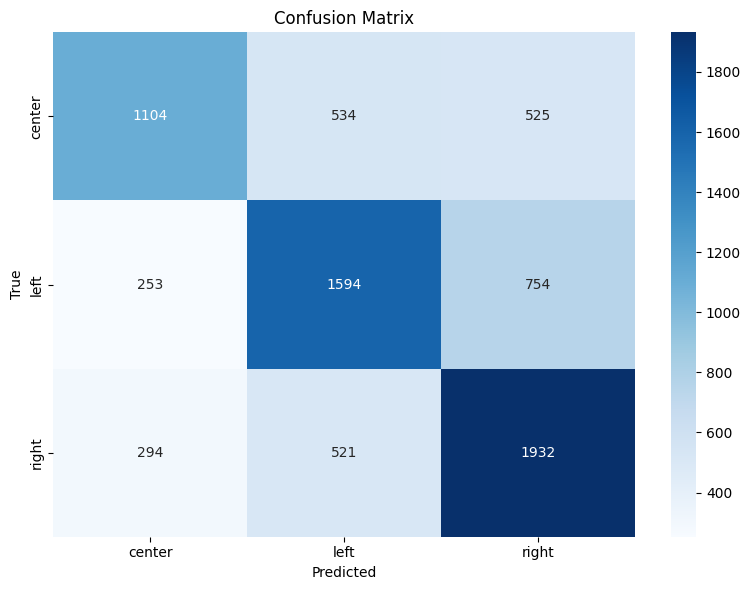

In [8]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Model Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['accuracy'], label='Training Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Model Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Make predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {accuracy:.4f}")

# Classification report
print("\nClassification Report:")
class_names = label_encoder.classes_
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:\n{cm}")

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

## 8. Make Predictions on New Data

Use the trained model to predict bias on new articles.

In [9]:
def predict_bias(text, model, tokenizer, label_encoder, max_length=500):
    """Predict bias of a new article"""
    # Preprocess
    cleaned_text = preprocess_text(text)
    
    # Tokenize
    sequence = tokenizer.texts_to_sequences([cleaned_text])
    padded = pad_sequences(sequence, maxlen=max_length, padding='post', truncating='post')
    
    # Predict
    prediction = model.predict(padded, verbose=0)
    predicted_class = np.argmax(prediction[0])
    confidence = prediction[0][predicted_class]
    predicted_label = label_encoder.inverse_transform([predicted_class])[0]
    
    return {
        'text': text[:200],
        'predicted_bias': predicted_label,
        'confidence': confidence,
        'probabilities': {label: float(pred) for label, pred in zip(label_encoder.classes_, prediction[0])}
    }

# Test on some articles from the dataset
print("Predictions on test set articles:\n")
for i in range(5):
    idx = np.random.randint(0, len(X_test))
    article_text = df.iloc[idx]['content']
    actual_bias = df.iloc[idx]['bias_text']
    
    result = predict_bias(article_text, model, tokenizer, label_encoder)
    
    print(f"Article {i+1}:")
    print(f"  Text: {result['text']}...")
    print(f"  Actual bias: {actual_bias}")
    print(f"  Predicted bias: {result['predicted_bias']}")
    print(f"  Confidence: {result['confidence']:.4f}")
    print(f"  Probabilities: {result['probabilities']}")
    print()

# Test on custom article
custom_article = """
The government's new environmental policy shows promising progress in addressing climate change. 
Scientists agree that these measures are crucial for our future. The administration has demonstrated 
a strong commitment to sustainability and renewable energy sources.
"""

print("\nPrediction on custom article:")
result = predict_bias(custom_article, model, tokenizer, label_encoder)
print(f"Text: {result['text']}...")
print(f"Predicted bias: {result['predicted_bias']}")
print(f"Confidence: {result['confidence']:.4f}")
print(f"Probabilities: {result['probabilities']}")

Predictions on test set articles:



Article 1:
  Text: President Barack Obama checked off his pledge to visit all 50 states while in office with a commencement address at a South Dakota community college that he called a model for preparing young American...
  Actual bias: center
  Predicted bias: right
  Confidence: 0.6441
  Probabilities: {'center': 0.1790616363286972, 'left': 0.17680901288986206, 'right': 0.6441293954849243}



Article 2:
  Text: WASHINGTON ( ███ ) - U.S. President Donald Trump ’ s administration touted its $ 660 billion small business pandemic aid program this week as a “ wild success , ” unveiling data that showed the initia...
  Actual bias: center
  Predicted bias: center
  Confidence: 0.9238
  Probabilities: {'center': 0.9237505197525024, 'left': 0.019216734915971756, 'right': 0.05703277140855789}

Article 3:
  Text: U.S. stocks edged closer to a bear market , defined as a drop of 20 % from its record , while a measure of fear on Wall Street reached its highest level since the 2008 financial crisis . European stoc...
  Actual bias: left
  Predicted bias: center
  Confidence: 0.6138
  Probabilities: {'center': 0.61384117603302, 'left': 0.2077057957649231, 'right': 0.17845302820205688}



Article 4:
  Text: The Republican tax relief should have helped working families more , but the help it does give is a meaningful improvement over the status quo .
Earlier this week , my family received a disturbing pie...
  Actual bias: right
  Predicted bias: right
  Confidence: 0.7452
  Probabilities: {'center': 0.11812122166156769, 'left': 0.1366465836763382, 'right': 0.7452322244644165}



Article 5:
  Text: WASHINGTON — The eyes of the world will be on Hamburg , Germany this week , as President Trump and Russian President Vladimir Putin — whose long-distance relationship has already sparked months of deb...
  Actual bias: center
  Predicted bias: center
  Confidence: 0.7326
  Probabilities: {'center': 0.7326177954673767, 'left': 0.1120472252368927, 'right': 0.15533500909805298}


Prediction on custom article:


Text: 
The government's new environmental policy shows promising progress in addressing climate change. 
Scientists agree that these measures are crucial for our future. The administration has demonstrated ...
Predicted bias: left
Confidence: 0.3877
Probabilities: {'center': 0.2379513829946518, 'left': 0.38767701387405396, 'right': 0.37437161803245544}


## 9. Save Model and Artifacts

Save the trained model and preprocessing artifacts for future use.

In [10]:
# Create save directory under the Bias Classifier project root
save_dir = PROJECT_ROOT / 'bias_lstm_model'
save_dir.mkdir(parents=True, exist_ok=True)

# Save model
model_path = save_dir / 'bias_lstm_model.keras'
model.save(str(model_path))
print(f"Model saved to {model_path}")

# Save tokenizer
tokenizer_path = save_dir / 'tokenizer.pkl'
with open(tokenizer_path, 'wb') as f:
    pickle.dump(tokenizer, f)
print(f"Tokenizer saved to {tokenizer_path}")

# Save label encoder
encoder_path = save_dir / 'label_encoder.pkl'
with open(encoder_path, 'wb') as f:
    pickle.dump(label_encoder, f)
print(f"Label encoder saved to {encoder_path}")

# Save metadata
metadata = {
    'max_words': MAX_WORDS,
    'max_sequence_length': MAX_SEQUENCE_LENGTH,
    'num_classes': NUM_CLASSES,
    'class_names': list(label_encoder.classes_),
    'accuracy': float(accuracy),
    'model_parameters': {
        'embedding_dim': EMBEDDING_DIM,
        'lstm_units': LSTM_UNITS,
        'dropout_rate': DROPOUT_RATE
    }
}

metadata_path = save_dir / 'metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"Metadata saved to {metadata_path}")

print(f"\nAll artifacts saved to {save_dir}")

Model saved to /mnt/c/jh/python2/Bias Classifier/bias_lstm_model/bias_lstm_model.keras


Tokenizer saved to /mnt/c/jh/python2/Bias Classifier/bias_lstm_model/tokenizer.pkl
Label encoder saved to /mnt/c/jh/python2/Bias Classifier/bias_lstm_model/label_encoder.pkl
Metadata saved to /mnt/c/jh/python2/Bias Classifier/bias_lstm_model/metadata.json

All artifacts saved to /mnt/c/jh/python2/Bias Classifier/bias_lstm_model
